# <span style="color:#c8a2c8; font-weight:bold">Irene's visuals notebook</span>

In [ ]:
# imports configuration
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap


# forcing pandas to display whole url
pd.set_option('display.max_colwidth', None)

# pforcing pandas to display all the columns
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.min_rows', 1000)
pd.set_option('display.width', 1000)
pd.set_option('display.max_seq_items', None)

# path to final cleaned dataset in data/cleaned
CLEANED_CSV_PATH = "../data/cleaned/properties_final_irene.csv"
ANALYSIS_OUTPUT_PATH = "../data/cleaned/properties_final_irene_after_analysis.csv"
DEEP_ANALYSIS_OUTPUT_PATH = "../data/cleaned/properties_final_irene_after_DEEP_analysis.csv"
GEO_CSV_PATH = "../data/cleaned/properties_final_irene_geo.csv"
# path to plots directory
PLOTS_PATH = "../images/"
# path to Belgium geojson
BE_GEOJSON_PATH = "../data/cleaned/belgium.geojson"
PC_GEOJSON_PATH = "../data/cleaned/code-postaux-belge.geojson"

# reading the file
data_df = pd.read_csv(CLEANED_CSV_PATH)

# checking dataset
data_df.describe(include='all')

,property_type,property_subtype,price,living_area_m2,bedrooms,bathrooms,address,postal_code,city,latitude,longitude,building_year,state_of_the_building,furnished,has_garage,parking_count,kitchen_equipped,has_elevator,facades,floors_total,has_garden,garden_area_m2,has_terrace,total_area_m2,epc_score,region,province,nearby_city,km_from_nearby_city,is_nearby_city_prestigious,floor_number,property_url,coord_swapped,price_per_m2
count,12399,12399,1.239900e+04,11557.000000,11987.000000,11036.000000,9949,12399.000000,12399,12397.000000,12397.000000,7433.000000,9541,12399.000000,12399.000000,4222.000000,3375,12399.000000,9375.00000,5581.000000,12399.000000,2780.000000,12399.000000,6892.000000,10445,12399,12399,12397,12397.000000,12397.000000,3508.000000,12399,12399,11557.000000
unique,2,15,NaN,NaN,NaN,NaN,9378,NaN,1601,NaN,NaN,NaN,8,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,3,11,44,NaN,NaN,NaN,12390,2,NaN
top,House,residence,NaN,NaN,NaN,NaN,Dessauerplein 1,NaN,Liege,NaN,NaN,NaN,Normal,NaN,NaN,NaN,Fully equipped,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,Wallonia,Liège,Bruxelles,NaN,NaN,NaN,https://immovlan.be/en/detail/residence/for-sale/7080/noirchain/vbe33505,False,NaN
freq,8023,6506,NaN,NaN,NaN,NaN,33,NaN,267,NaN,NaN,NaN,3665,NaN,NaN,NaN,1604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2093,5988,1722,1386,NaN,NaN,NaN,2,12355,NaN
mean,NaN,NaN,3.994536e+05,173.569525,3.078335,1.411290,NaN,5014.645294,NaN,50.720212,4.548858,1970.027849,NaN,0.036051,0.451246,1.860966,NaN,0.193241,2.95904,3.313922,0.536817,1232.853237,0.658279,1560.218659,NaN,NaN,NaN,NaN,35.256344,0.062999,3.541334,NaN,NaN,2579.397854
std,NaN,NaN,3.708000e+05,156.447090,2.275741,1.168308,NaN,2678.774296,NaN,0.371949,0.816695,47.241161,NaN,0.186425,0.497637,29.254179,NaN,0.394857,0.87970,2.936057,0.498663,5413.624467,0.474306,5068.651525,NaN,NaN,NaN,NaN,388.588079,0.242971,29.262686,NaN,NaN,1397.459709
min,NaN,NaN,1.990000e+04,12.000000,1.000000,1.000000,NaN,1000.000000,NaN,49.506790,2.509162,1500.000000,NaN,0.000000,0.000000,1.000000,NaN,0.000000,1.00000,1.000000,0.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,106.000000
25%,NaN,NaN,1.950000e+05,90.000000,2.000000,1.000000,NaN,2570.000000,NaN,50.471983,4.155752,1950.000000,NaN,0.000000,0.000000,1.000000,NaN,0.000000,2.00000,2.000000,0.000000,117.000000,0.000000,267.750000,NaN,NaN,NaN,NaN,3.200000,0.000000,1.000000,NaN,NaN,1702.000000
50%,NaN,NaN,3.025000e+05,145.000000,3.000000,1.000000,NaN,4960.000000,NaN,50.771942,4.462025,1975.000000,NaN,0.000000,0.000000,1.000000,NaN,0.000000,3.00000,3.000000,1.000000,352.500000,1.000000,629.000000,NaN,NaN,NaN,NaN,8.400000,0.000000,2.000000,NaN,NaN,2400.000000
75%,NaN,NaN,4.990000e+05,207.000000,4.000000,2.000000,NaN,7100.000000,NaN,51.009126,5.237860,2007.000000,NaN,0.000000,1.000000,1.000000,NaN,0.000000,4.00000,4.000000,1.000000,900.000000,1.000000,1316.250000,NaN,NaN,NaN,NaN,17.000000,0.000000,3.000000,NaN,NaN,3158.000000


## <span style="color:#c8a2c8">1. Data Volume and Integrity</span>

### **Q1**: How many observations and features/columns do you have?

*Our strategy is based on a dataset which includes almost 12400 properties across Belgium.*

### **Q2**: What is the proportion of missing values per column?

In [2]:
# functions
def missing_values_proportions(df, analysis_checkpoint):
    """
    calculates and returns proportions of missing values in df.
    """
    missing_prop = (df.isnull().sum() / len(df)) * 100
    if analysis_checkpoint in ["BEFORE ANALYSIS", "AFTER PHASE 2", "AFTER PHASE 3"]:
        missing_prop = missing_prop[(missing_prop > 0)].sort_values(ascending=False)
    elif analysis_checkpoint == "AFTER PHASE 1":
        missing_prop = missing_prop[(missing_prop >= 50)].sort_values(ascending=False)
    return missing_prop

# generation of plots
def generate_df_structure_barplot(df, analysis_checkpoint):
    """
    creates, saves in images folder and shows barplot displaying nan values distribution in df.
    """
    plt.figure(figsize=(10,6))
    structure_bar = sns.barplot(
        x=missing_values_proportions(df, analysis_checkpoint).values, 
        y=missing_values_proportions(df, analysis_checkpoint).index, 
        hue=missing_values_proportions(df, analysis_checkpoint).index,
        palette="viridis",
        legend=False
    )
    plt.title(
        "Proportion of Missing Values per Column (%)",
        fontsize=14,
        pad=15
    )
    plt.xlabel(
        "Percentage (%)",
        fontsize=12
    )
    plt.ylabel(
        "Columns",
        fontsize=12
    )
    structure_bar.set_title(f"Dataset Strucutre Visual - Missing Values % per Column {analysis_checkpoint}")
    sns.despine()
    plt.savefig(
        f"{PLOTS_PATH}structure_barplot_in_{analysis_checkpoint}.png", 
        bbox_inches='tight', 
        dpi=330
    )
    plt.show()
    plt.close()

============================== DATASET STRUCTURE BEFORE ANALYSIS ==============================


Number of (motionless) observations: 12399

Number of properties features (columns): 34



============================== MISSING VALUES ==============================


Percentage of missing values for each column BEFORE ANALYSIS:


garden_area_m2                77.578837
kitchen_equipped              72.780063
floor_number                  71.707396
parking_count                 65.948867
floors_total                  54.988306
total_area_m2                 44.414872
building_year                 40.051617
facades                       24.389064
state_of_the_building         23.050246
address                       19.759658
epc_score                     15.759335
bathrooms                     10.992822
price_per_m2                   6.790870
living_area_m2                 6.790870
bedrooms                       3.322849
latitude                       0.016130
longitude                   

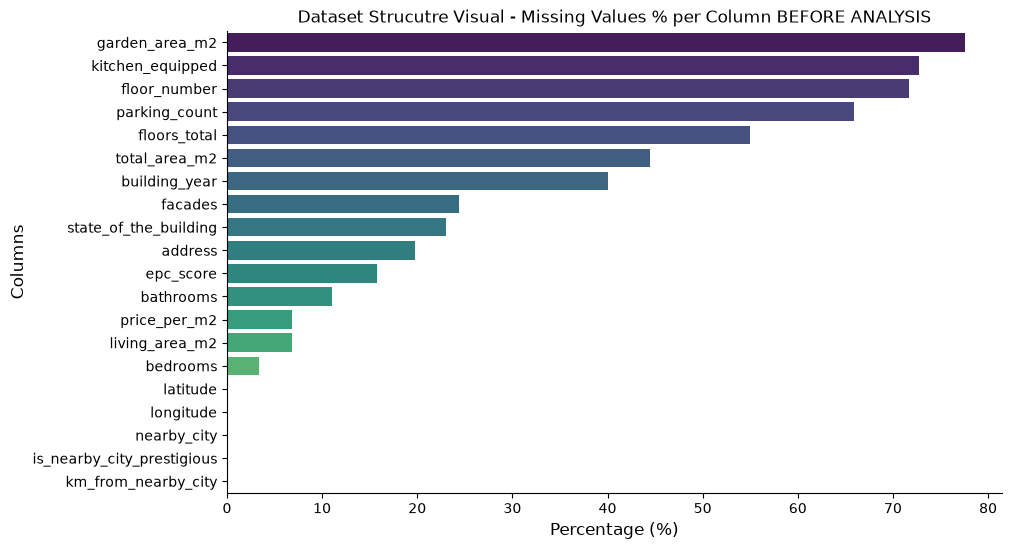

Barplot successfully saved in ../images/structure_barplot BEFORE ANALYSIS.png


In [3]:
checkpoint = "BEFORE ANALYSIS"

print("="*30 + f" DATASET STRUCTURE {checkpoint} " + "="*30)
print("\n")
print(f"Number of (motionless) observations: {data_df.shape[0]}\n")
print(f"Number of properties features (columns): {data_df.shape[1]}\n")
print("\n")

print("="*30 + " MISSING VALUES " + "="*30)
print("\n")
print(f"Percentage of missing values for each column {checkpoint}:")
print("\n")
print(missing_values_proportions(data_df, checkpoint))
print("\n")

# data structure visual
generate_df_structure_barplot(data_df, checkpoint)
print(f"Barplot successfully saved in {PLOTS_PATH}structure_barplot {checkpoint}.png")


Missing data may be **Random** (for instance, 'price') or **Structural** (for instance, 'garden_area_m2').  

Here how I am going to treat them:
- **Phase 1 - false missing handling**: if possible, conversion to boolean variable ("is there"/"is not there");
- **Phase 2 - higher than than 50%**: removal of the row otherwise;
- **Phase 3_MID - between 5% and 50%**: regressive model (IterativeImputer);
- **Phase 3_LOW - less than 5%**: minimal noise -> simple amputation (median for numeric values, mode for categorical values).

#### **<u>Phase 1</u>: Remediation of "False Missing"**
Conditional pairs:
- *'has_garden'* / *'garden_area_m2'* - if 'has_garden' is 0, 'garden_area_m2' should be 0
- *'has_terrace'* / *'terrace_area_m2'* - if 'has_terrace' is 0, 'terrace_area_m2' should be 0
- *'floor_number'* / *'property_type'* - if 'property_type' is 'House', 'floor_number' should be -999

I assign a ***sentinel value*** to values in *'floor_number'* of rows with 'House' in *'property_type'*.

Converting to 0 if boolean flag indicates absence of the element:

In [4]:
# garden
data_df.loc[(data_df['has_garden'] == 0), 'garden_area_m2'] = 0

# terrace
data_df.loc[(data_df['has_terrace'] == 0), 'terrace_area_m2'] = 0

# floor number
data_df.loc[(data_df['property_type'] == 'House'), 'floor_number'] = -999

# Saving changes in properties_final_irene_after_analysis.csv
data_df.to_csv(ANALYSIS_OUTPUT_PATH, index=False)

Check Missing Values Proportions after Phase 1:

In [5]:
checkpoint = "AFTER PHASE 1"

print("="*30 + f" MISSING VALUES {checkpoint} " + "="*30)
print("\n")
print(f"Columns with missing values proportions higher than 50% and relative percentages {checkpoint}:")
print("\n")
print(missing_values_proportions(data_df, checkpoint))

============================== MISSING VALUES AFTER PHASE 1 ==============================


Columns with missing values proportions higher than 50% and relative percentages AFTER PHASE 1:


kitchen_equipped    72.780063
parking_count       65.948867
terrace_area_m2     65.827889
floors_total        54.988306
dtype: float64


These are the candidate columns for Phase 2.

#### **<u>Phase 2</u>: Hard Pruning**
- *'kitchen_equipped'* &rarr; only 27% of properties in dataset has certainly an equipped kitchen, this means that to more than 70% could only be attributed an invented feature causing fouling of the model &rarr; **TO BE ELIMINATED**
- *'terrace_area_m2'* &rarr; still very high after boolean conversion, compared to *'garden_area_m2'* that, instead, went below 50% nan; need to check if it's just due to propagation error or not before removal &rarr; **ELIMINATE IF NAN NOT PRESENT**
- *'parking_count'* &rarr; same as 'kitchen_equipped' &rarr; **TO BE ELIMINATED**
- *'floors_total'* &rarr; same as 'kitchen_equipped' and 'parking_count' &rarr; **TO BE ELIMINATED**

In [6]:
# terrace_area_m2 check control boolean variable status
print(data_df['has_terrace'].value_counts(dropna=False))

has_terrace
1    8162
0    4237
Name: count, dtype: int64


No nan values left in 'has_terrace' column &rarr; *'terrace_area_m2'*  **TO BE ELIMINATED**

In [7]:
# save a copy of dataset before phase 2
whole_df = data_df.copy()

columns_to_remove = ['kitchen_equipped', 'terrace_area_m2', 'parking_count', 'floors_total']
data_df = data_df.drop(columns=columns_to_remove, errors='ignore')

# Saving changes in properties_final_irene_after_analysis.csv
data_df.to_csv(ANALYSIS_OUTPUT_PATH, index=False)

print(f"Columns:\n{', '.join(columns_to_remove)}\nhave been successfully removed from the dataset.")

Columns:
kitchen_equipped, terrace_area_m2, parking_count, floors_total
have been successfully removed from the dataset.


Check Missing Values Proportions after Phase 2:

In [8]:
checkpoint = "AFTER PHASE 2"

print("="*30 + f" MISSING VALUES {checkpoint} " + "="*30)
print("\n")
print(f"Percentage of missing values for each column {checkpoint}:")
print("\n")
display(missing_values_proportions(data_df, checkpoint))

============================== MISSING VALUES AFTER PHASE 2 ==============================


Percentage of missing values for each column AFTER PHASE 2:




total_area_m2                 44.414872
building_year                 40.051617
garden_area_m2                31.260586
facades                       24.389064
state_of_the_building         23.050246
address                       19.759658
epc_score                     15.759335
bathrooms                     10.992822
floor_number                   7.000565
living_area_m2                 6.790870
price_per_m2                   6.790870
bedrooms                       3.322849
latitude                       0.016130
longitude                      0.016130
nearby_city                    0.016130
is_nearby_city_prestigious     0.016130
km_from_nearby_city            0.016130
dtype: float64

#### **<u>Phase 3</u>: Imputation Pipeline Orchestration**

##### **3.1 - Official pipeline**: handling of missings

**LOW - < 5%**  
Minimal impact on variance &rarr; substitution with median for:    
    - *'bedrooms'* 

**MID - between 5% and 50%**  
Substitution with median would affect data distribution due to too much high nan proportion &rarr; usage of predictive algorithms that estimate missing value by looking at record columns. This aproach will be applied to:  
    - *'building_year'*  
    - *'state_of_the_building'*  
    - *'bathrooms'*  
    - *'living_area_m2'*  
    - *'price_per_m2'*  
    - *'floor_number'*  
    - *'epc_score'* &rarr; *must be converted to ints with a dictionary*  
    - *'address'*  
    - *'facades'*  
    - *'garden_area_m2'*  
    - *'total_area_m2'*  

Converting epc_scores to a number each

In [9]:
print(data_df['epc_score'].unique())

epc_scores = ["A++", "A+", "A", "B", "C", "D", "E", "F", "G"]
epc_mapping = {
    "A++" : 1,
    "A+" : 2, 
    "A" : 3, 
    "B+": 4,
    "B" : 5,
    "C" : 6,
    "D" : 7,
    "E+": 8,
    "E" : 9, 
    "F" : 10,
    "G" : 11
}

data_df['epc_score'] = data_df['epc_score'].replace(epc_mapping)
whole_df['epc_score'] = whole_df['epc_score'].replace(epc_mapping)

# Saving changes in data/cleaned
data_df.to_csv(ANALYSIS_OUTPUT_PATH, index=False) 
whole_df.to_csv(DEEP_ANALYSIS_OUTPUT_PATH, index=False)

print("Values in 'epc_score' have been successfully replaced with int values.")

<StringArray>
['A+', 'B', 'G', nan, 'D', 'C', 'A', 'E', 'F', 'A++', 'B+', 'E+']
Length: 12, dtype: str
Values in 'epc_score' have been successfully replaced with int values.


**Running Imputation with Scikitlearn on dataframe data_df**

In [10]:
sklearn.set_config(transform_output="pandas")

print("="*30 + f" 3.1 - FIRST IMPUTATION " + "="*30)

# removing whole row where Nan in 'latitude' is found
data_df =data_df.dropna(subset=['latitude']).copy()

low_missing_numeric = ['bedrooms']
mid_missing_numeric = [
    'building_year', 'bathrooms', 'living_area_m2', 
    'price_per_m2', 'floor_number', 'facades', 
    'garden_area_m2', 'total_area_m2','epc_score'
]
print(data_df[mid_missing_numeric].isna().sum())
mid_missing_literal = ['state_of_the_building', 'address']

# Simple Imputation (median and most frequent value)
num_imputer = SimpleImputer(strategy='median')
lit_imputer = SimpleImputer(strategy='most_frequent')

data_df[low_missing_numeric] = num_imputer.fit_transform(data_df[low_missing_numeric])
data_df[mid_missing_literal] = lit_imputer.fit_transform(data_df[mid_missing_literal])

# balanced KNNImputation: scale -> Imputat -> de-scale
scaler = StandardScaler()
knn_imputer = KNNImputer(n_neighbors=5)

numeric_scaled = scaler.fit_transform(data_df[mid_missing_numeric])
numeric_imputed_scaled = knn_imputer.fit_transform(numeric_scaled)
numeric_final = scaler.inverse_transform(numeric_imputed_scaled)

# re inserting data with relative scale in df
data_df[mid_missing_numeric] = numeric_final

# correction of float64 data from KNNImputer 
cols_to_int = [
    'bedrooms',
    'building_year',
    'bathrooms',
    'living_area_m2', 
    'price_per_m2', 
    'floor_number', 
    'facades', 
    'garden_area_m2', 
    'total_area_m2',
    'epc_score',
]
# conversion of only actually present columns
cols_to_int = [c for c in cols_to_int if c in data_df.columns]
data_df[cols_to_int] = data_df[cols_to_int].round().astype(int)

# Logic fix: correction on floor number in case of houses
if 'property_type' in data_df.columns and 'floor_number' in data_df.columns:
    data_df.loc[data_df['property_type'] == "House", "floor_number"] = 0


# Saving changes in properties_final_irene_after_analysis.csv
data_df.to_csv(ANALYSIS_OUTPUT_PATH, index=False)

print(f"Residual missings: {data_df.isna().sum().sum()}")


============================== 3.1 - FIRST IMPUTATION ==============================
building_year     4964
bathrooms         1363
living_area_m2     842
price_per_m2       842
floor_number       867
facades           3024
garden_area_m2    3876
total_area_m2     5505
epc_score         1954
dtype: int64
Residual missings: 0


Checking dataset structure after analysis

============================== DATASET STRUCTURE AFTER PHASE 3 ==============================


Number of (motionless) observations: 12397

Number of properties features (columns): 31



============================== MISSING VALUES ==============================


Percentage of missing values for each column AFTER PHASE 3:


Series([], dtype: float64)




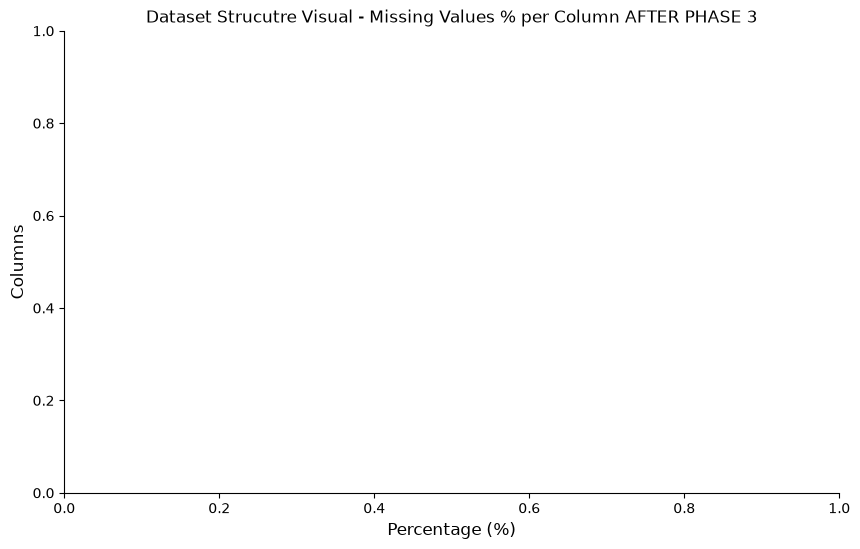

Barplot successfully saved in ../images/structure_barplot AFTER PHASE 3.png


In [11]:
checkpoint = "AFTER PHASE 3"

print("="*30 + f" DATASET STRUCTURE {checkpoint} " + "="*30)
print("\n")
print(f"Number of (motionless) observations: {data_df.shape[0]}\n")
print(f"Number of properties features (columns): {data_df.shape[1]}\n")
print("\n")

print("="*30 + " MISSING VALUES " + "="*30)
print("\n")
print(f"Percentage of missing values for each column {checkpoint}:")
print("\n")
print(missing_values_proportions(data_df, checkpoint))
print("\n")

# data structure visual
generate_df_structure_barplot(data_df, checkpoint)
print(f"Barplot successfully saved in {PLOTS_PATH}structure_barplot {checkpoint}.png")

## <span style="color:#c8a2c8">2. Bonus Insights</span>

In [12]:
data_df.describe(include='all')

,property_type,property_subtype,price,living_area_m2,bedrooms,bathrooms,address,postal_code,city,latitude,longitude,building_year,state_of_the_building,furnished,has_garage,has_elevator,facades,has_garden,garden_area_m2,has_terrace,total_area_m2,epc_score,region,province,nearby_city,km_from_nearby_city,is_nearby_city_prestigious,floor_number,property_url,coord_swapped,price_per_m2
count,12397,12397,1.239700e+04,12397.000000,12397.000000,12397.000000,12397,12397.000000,12397,12397.000000,12397.000000,12397.000000,12397,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000,12397,12397,12397,12397.000000,12397.000000,12397.000000,12397,12397,12397.000000
unique,2,15,NaN,NaN,NaN,NaN,9378,NaN,1601,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,11,44,NaN,NaN,NaN,12388,2,NaN
top,House,residence,NaN,NaN,NaN,NaN,Dessauerplein 1,NaN,Liege,NaN,NaN,NaN,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wallonia,Liège,Bruxelles,NaN,NaN,NaN,https://immovlan.be/en/detail/residence/for-sale/7080/noirchain/vbe33505,False,NaN
freq,8023,6506,NaN,NaN,NaN,NaN,2481,NaN,267,NaN,NaN,NaN,6521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5986,1722,1386,NaN,NaN,NaN,2,12353,NaN
mean,NaN,NaN,3.994998e+05,174.287328,3.075905,1.436477,NaN,5014.542793,NaN,50.720212,4.548858,1975.526256,NaN,0.036057,0.451238,0.193273,2.861741,0.536904,312.548278,0.658304,1339.309510,7.046382,NaN,NaN,NaN,35.256344,0.062999,-50.738485,NaN,NaN,2565.808341
std,NaN,NaN,3.708120e+05,154.077635,2.237791,1.138279,NaN,2678.978230,NaN,0.371949,0.816695,40.071855,NaN,0.186440,0.497637,0.394881,0.830458,0.498656,2641.168089,0.474297,4072.626085,2.424270,NaN,NaN,NaN,388.588079,0.242971,198.474663,NaN,NaN,1362.344814
min,NaN,NaN,1.990000e+04,12.000000,1.000000,1.000000,NaN,1000.000000,NaN,49.506790,2.509162,1500.000000,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000,-999.000000,NaN,NaN,106.000000
25%,NaN,NaN,1.950000e+05,92.000000,2.000000,1.000000,NaN,2570.000000,NaN,50.471983,4.155752,1959.000000,NaN,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,235.000000,5.000000,NaN,NaN,NaN,3.200000,0.000000,0.000000,NaN,NaN,1732.000000
50%,NaN,NaN,3.030000e+05,145.000000,3.000000,1.000000,NaN,4960.000000,NaN,50.771942,4.462025,1980.000000,NaN,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,1.000000,526.000000,7.000000,NaN,NaN,NaN,8.400000,0.000000,0.000000,NaN,NaN,2388.000000
75%,NaN,NaN,4.990000e+05,208.000000,4.000000,2.000000,NaN,7100.000000,NaN,51.009126,5.237860,2005.000000,NaN,0.000000,1.000000,0.000000,4.000000,1.000000,30.000000,1.000000,1105.000000,9.000000,NaN,NaN,NaN,17.000000,0.000000,1.000000,NaN,NaN,3125.000000


1. Quadrant Analysis (Risk/Return Matrix)
Do not create complex new charts. Create a Quadrant (X-axis: Average price per m²; Y-axis: Appreciation potential/Average EPC rating).

What to include: Divide the market into four zones:

High Value / Low Risk: Areas like Brussels (stable).

High Opportunity / Medium Risk: Areas with low EPC ratings (e.g., older buildings) but competitive pricing (where you can renovate and unlock value).

Rationale: Show investors that you are not simply looking for the cheapest homes, but rather for the location with the greatest value delta (purchase price vs. potential value after achieving an EPC A rating).

Average price per m² by energy class:
epc_score
1     3159.370370
2     2606.723913
3     3422.096698
4     2780.800000
5     2946.825758
6     2601.207290
7     2458.343635
8     2792.076782
9     2313.366840
10    2162.287212
11    2155.833654
Name: price_per_m2, dtype: float64
Price difference: 46.5%


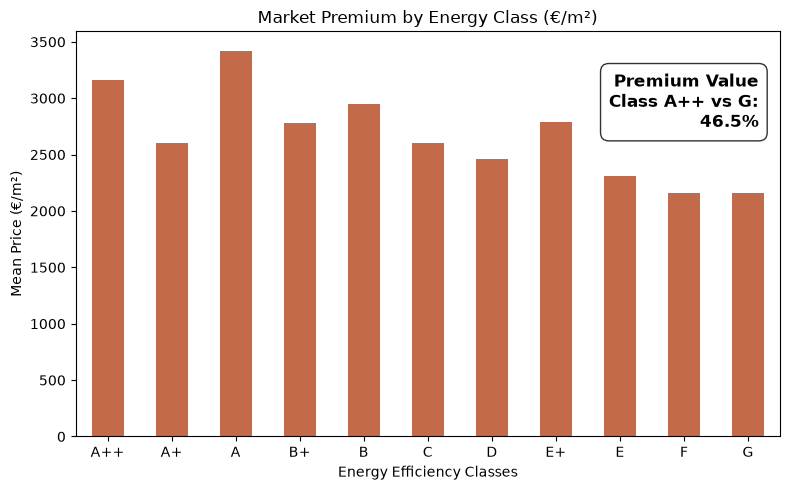

In [16]:
plt.close('all')

# extract the average price per square meter by energy class.

df = pd.read_csv(ANALYSIS_OUTPUT_PATH)
df_clean = df.dropna(subset=['epc_score', 'price_per_m2'])

epc_analysis = df_clean.groupby('epc_score')['price_per_m2'].mean().sort_index()

print(f"Average price per m² by energy class:")
print(epc_analysis)

# calculating difference
best_class_idx = epc_analysis.index.min()
worst_class_idx = epc_analysis.index.max()
best_val = epc_analysis[best_class_idx]
worst_val = epc_analysis[worst_class_idx]

diff = ((best_val - worst_val) / worst_val) * 100
print(f"Price difference: {diff:.1f}%")

# epc_scores labels mapping
label_mapping = {1: "A++", 2: "A+", 3: "A", 4: "B+", 5: "B", 6: "C", 7: "D", 8: "E+", 9: "E", 10: "F", 11: "G"}
plot_data = epc_analysis.rename(index=label_mapping)

fig, ax = plt.subplots(figsize=(8,5))
plot_data.plot(kind='bar', color='#c26a4a', ax=ax, legend=False)

plt.title("Market Premium by Energy Class (€/m²)")
plt.ylabel("Mean Price (€/m²)")
plt.xlabel("Energy Efficiency Classes")
plt.xticks(rotation=0)

ax.text(
    x=0.97, 
    y=0.9,
    s=f"Premium Value\nClass A++ vs G:\n{diff:.1f}%",
    fontsize=12, 
    fontweight='bold',
    ha='right',
    va='top',
    transform=ax.transAxes,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.5')
)

plt.savefig(
    f"{PLOTS_PATH}barplot_Market_Premium_by_Energy_Class.png", 
    bbox_inches='tight', 
    dpi=150
) 

plt.tight_layout()
plt.show()
plt.close()